# Librerías a importar

## Path a usar para cargar datasets y modulos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error, 
                             mean_absolute_percentage_error, explained_variance_score, 
                             median_absolute_error)
from sklearn.mixture import GaussianMixture
from alibi_detect.cd import KSDrift
from pathlib import Path
import sys
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline


PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


from src.mlops.dataset import (load_data, dataset_split, clean_holiday_column, 
                           clean_functioning_day, clean_seasons, clean_mixed_type, 
                           clean_weather_features, clean_date_hour, clean_hour, 
                           clean_target, clean_date_column)

from src.mlops.preprocess import build_preprocessing_pipeline, delete_outliers

from src.mlops.features import create_time_features, encode_categorical_features

# Clases DataCleaner y FeatureEngineering

In [2]:
class DataCleaner(BaseEstimator, TransformerMixin):
    
    """
    Clase encargada de limpiar y depurar el conjunto de datos antes del modelado.

    La clase `DataCleaner` aplica de forma secuencial todas las funciones de limpieza 
    definidas en el pipeline, asegurando la consistencia, completitud y calidad del 
    dataset. Implementa la interfaz de Scikit-Learn (`BaseEstimator`, `TransformerMixin`) 
    para integrarse fácilmente en pipelines de preprocesamiento.

    Métodos
    -------
    fit(X, y=None)
        Método requerido por la API de Scikit-Learn. No realiza ajustes y retorna la propia instancia.
    transform(X)
        Aplica las distintas funciones de limpieza sobre una copia del DataFrame original, 
        incluyendo corrección de fechas, tratamiento de valores nulos, estandarización de 
        variables categóricas, limpieza de datos meteorológicos, eliminación de outliers 
        y validación de la variable objetivo.

    Parámetros
    ----------
    X : pandas.DataFrame
        Dataset original con las variables crudas antes de la limpieza.
    y : Ignorado, opcional
        Parámetro incluido por compatibilidad con la API de Scikit-Learn.

    Retorna
    -------
    pandas.DataFrame
        DataFrame completamente limpio y listo para las etapas de ingeniería de características.
    """

    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df = X.copy()
        df = clean_date_column(df)
        df = clean_holiday_column(df)
        df = clean_functioning_day(df)
        df = clean_seasons(df)
        df = clean_mixed_type(df)
        df = clean_weather_features(df)
        df = clean_target(df)
        df = clean_date_hour(df)
        df = delete_outliers(df)
        df = clean_hour(df)
        return df
    

class FeatureEngineering(BaseEstimator, TransformerMixin):
    
    """
    Clase encargada de generar características temporales a partir de la columna de fecha.

    La clase `FeatureEngineering` implementa la lógica de creación de variables derivadas 
    del tiempo mediante la función `create_time_features`. Agrega columnas como año, mes, 
    día de la semana, día del año y sus representaciones cíclicas para capturar patrones 
    temporales relevantes en el modelo.

    Métodos
    -------
    fit(X, y=None)
        Método requerido por la API de Scikit-Learn. No realiza ajustes y retorna la propia instancia.
    transform(X)
        Aplica la función `create_time_features` sobre una copia del DataFrame para generar 
        las nuevas variables temporales.

    Parámetros
    ----------
    X : pandas.DataFrame
        Dataset limpio previo a la generación de características.
    y : Ignorado, opcional
        Parámetro incluido por compatibilidad con la API de Scikit-Learn.

    Retorna
    -------
    pandas.DataFrame
        DataFrame enriquecido con variables temporales y codificaciones cíclicas.
    """

    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df = X.copy()
        df = create_time_features(df)
        return df

# Cargamos nuestro dataset

Aplicamos los siguientes pasos a nuestro dataset para usarlo más adelante:

- Carga 
- Limpieza
- Feature Engineering
- Train-Test split

In [3]:
# Cargamos el dataset sin procesar
data_path = '../data/raw/seoul_bike_sharing_modified.csv'
df = load_data(data_path)

# Aplicamos la limpieza primero con Datacleaner
cleaner = DataCleaner()
df_cleaned = cleaner.fit_transform(df)

# Luego aplicamos el feature engineering
FE = FeatureEngineering()
df_featured = FE.fit_transform(df_cleaned)

# Generamos nuestros sets de entrenamiento y test
X_train, X_test, y_train, y_test = dataset_split(
        df_featured,
        target='demanda',        
        test_size=0.3,
        random_state=42 
    )

2025-11-13 20:40:21,561 [INFO] Se cargó el siguiente dataset: seoul_bike_sharing_modified.csv ✅
2025-11-13 20:40:21,563 [INFO] Dimensiones del dataset cargado: 8935 files y 15 columnas
/home/delbs/MLOps_Project/MLOps-entregas/src/mlops/dataset.py:518: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f"{col}"] = df[f"{col}"].fillna(method= 'ffill')
/home/delbs/MLOps_Project/MLOps-entregas/src/mlops/dataset.py:519: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f"{col}"] = df[f"{col}"].fillna(method= 'bfill')
2025-11-13 20:40:21,639 [INFO] ✅ Se cargaron los features temporales correctamente.
2025-11-13 20:40:21,647 [INFO] Se llevó a cabo el split: Train=5154 | Test=2209 | Target=demanda | ✅


# Generamos el modelo Baseline

Usando MLFlow obtuvimos los hiperparámetros de nuestro mejor modelo, por lo que implementamos directamente los mismos aquí.

In [15]:
# Features numericos y categoricos
numerical_features_to_use = [
        'hour', "temperature(°c)", "humidity(%)", "wind_speed_(m/s)",
        "visibility_(10m)", "dew_point_temperature(°c)", "solar_radiation_(mj/m2)",
        "rainfall(mm)", "snowfall_(cm)", "year", "month", "day_of_week", "day_of_year",
        "month_sin", "month_cos", "day_of_week_sin", "day_of_week_cos", "hour_sin", "hour_cos"
    ]

categorical_features_to_use = ["seasons", "holiday", "functioning_day"]


# Pipeline
preprocessor = build_preprocessing_pipeline(
    categorical_features=categorical_features_to_use, 
    numerical_features=numerical_features_to_use
)

#  Modelo a probar
xgboost_regressor = XGBRegressor(
    colsample_bytree=0.8,
    n_estimators=2000,
    random_state=42,
    learning_rate=0.1,
    subsample=0.8
    )

# Instanciamos la pipeline completa
model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", xgboost_regressor),
        ]
    )

# Entrenamos el modelo
model_pipeline.fit(X_train, y_train)

# Generamos las predicciones
y_pred = model_pipeline.predict(X_test)

# Guaradamos las metricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

baseline_metrics_dict = { "Variable_a_modificar" : "Ninguna", "mean_shift_%" : '0',
                "rmse": rmse, "mae": mae, "mape": mape, "r2": r2,
                "explained_variance": evs, "median_ae": medae, "mean_bias_error": mbe
            }

# Mostramos las métricas
print("\n\nResultados de modelo Baseline:") 
baseline_metrics_dict

2025-11-13 20:42:12,642 [INFO] Creando pipeline de pre-procesamiento
2025-11-13 20:42:12,644 [INFO] Se creo una pipeline de pre-procesamiento con 19 features numericos.y 3 features categoricos.




Resultados de modelo Baseline:


{'Variable_a_modificar': 'Ninguna',
 'mean_shift_%': '0',
 'rmse': 170.35837112724067,
 'mae': 92.31986852985882,
 'mape': 1.6441641054783332e+16,
 'r2': 0.9190327980708456,
 'explained_variance': 0.9190374978504611,
 'median_ae': 47.02363586425781,
 'mean_bias_error': -1.2979192090566043}

# Simulación de Drift

## KSDrift para variables numéricas

Procedemos a generar la función `test_numerical_drift` para ver cómo la implementación de un mean shift (desplazamiento de la media) afecta las predicciones de nuestro modelo.

Con esto, la idea es ver también el efecto del cambio de la distribución de los datos en las métricas de desempeño de nuestro mejor modelo.

In [21]:
def test_numerical_drift(feature, gmm_model, shift_to_test):
    
    # Cargamos el shift a probar
    mean_shift = shift_to_test
    
    # Mostramos las métricas originales del feature
    print("="*70)
    print(f"Medias originales de {feature}: \n", gmm_model.means_)
    
    # Empezamos a generar el shift en el feature
    modified_means     = gmm_model.means_.copy()
    modified_means *= (1 + mean_shift)
    
    # Mostramos las métricas del feature modificado
    gmm_model.means_ = modified_means
    print("="*70)
    print(f"\n\nMedias alteradas {feature}: \n", gmm_model.means_)
    
    
    synthetic_data = df_featured.copy()

    synthetic_data[feature] = gmm_model.sample(int(df_featured.describe()[feature]['count']))[0].reshape(-1)
    X_synthetic = synthetic_data[numerical_features_to_use + categorical_features_to_use]
    y_syntethic = synthetic_data['demanda']
    
    y_synthetic_pred = model_pipeline.predict(X_synthetic)

    rmse = np.sqrt(mean_squared_error(y_syntethic, y_synthetic_pred))
    r2 = r2_score(y_syntethic, y_synthetic_pred)
    mae = mean_absolute_error(y_syntethic, y_synthetic_pred)
    mape = mean_absolute_percentage_error(y_syntethic, y_synthetic_pred)
    evs = explained_variance_score(y_syntethic, y_synthetic_pred)
    medae = median_absolute_error(y_syntethic, y_synthetic_pred)
    mbe = np.mean(y_synthetic_pred - y_syntethic)

    metrics_dict = {"Variable_a_modificar" : f"{feature}", "mean_shift_%" : f"{shift_to_test}",
                    "rmse": rmse, "mae": mae, "mape": mape, "r2": r2,
                    "explained_variance": evs, "median_ae": medae, "mean_bias_error": mbe
                }
    
    # Usamos solo columnas numericas
    X_train_numeric = X_train[numerical_features_to_use]
    X_synthetic_numeric = X_synthetic[numerical_features_to_use]

    # Detectar drift
    cd = KSDrift(X_train_numeric.to_numpy(), p_val=0.05)
    drift_pred = cd.predict(X_synthetic_numeric.to_numpy())
    
    drift_result_dict = {
        1: 'Sí se detectó drift.', 0: 'No se detectó drift'
    }
    
    print("="*70)
    print(drift_result_dict[drift_pred['data']['is_drift']])
    
    plt.figure(figsize=(10,5))

    sns.kdeplot(
        df_featured[feature],
        label=f"{feature} - Original",
        fill=True,
        color='red'
    )

    sns.kdeplot(
        synthetic_data[feature],
        label=f'{feature} - Modificado',
        fill=True,
        color='blue'
    )

    # Título y etiquetas
    plt.title(f"Distribución KDE de {feature} (Original vs Modificado)", fontsize=14)
    plt.xlabel(f"{feature}", fontsize=12)
    plt.ylabel("Densidad", fontsize=12)

    # Leyenda
    plt.legend(title="Dataset")

    # Grid
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.show()
    
    print("="*70)
    print(f"Métricas obtenidas al modificar {feature}:\n")

    return metrics_dict

### Usando `dew_point_temperature`

Medias originales de dew_point_temperature(°c): 
 [[ -8.38510257]
 [ 20.18918619]
 [-18.23107845]
 [ 10.28269439]
 [  0.72037241]]


Medias alteradas dew_point_temperature(°c): 
 [[-10.48137821]
 [ 25.23648274]
 [-22.78884806]
 [ 12.85336799]
 [  0.90046552]]
Sí se detectó drift.


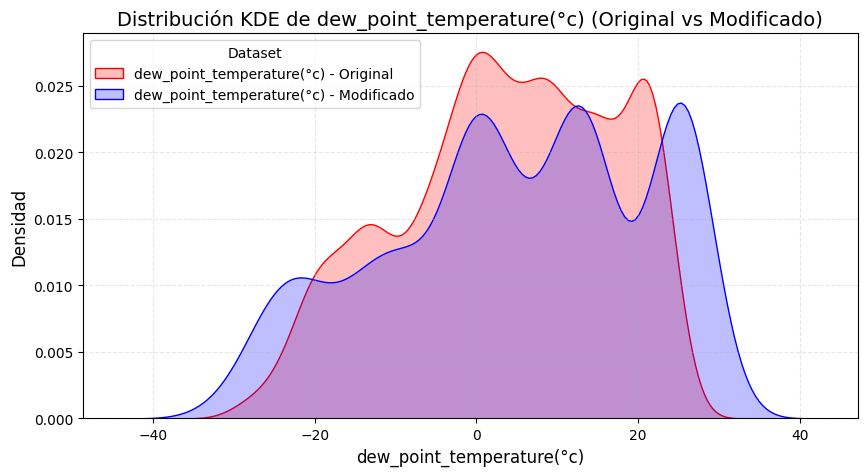

Métricas obtenidas al modificar dew_point_temperature(°c):



{'Variable_a_modificar': 'dew_point_temperature(°c)',
 'mean_shift_%': '0.25',
 'rmse': 152.9759007403429,
 'mae': 99.9016720968109,
 'mape': 1.5616684593329484e+16,
 'r2': 0.9343728554340293,
 'explained_variance': 0.9349534614830933,
 'median_ae': 61.405975341796875,
 'mean_bias_error': -14.388716072768936}

In [ ]:
# Usamos un modelo GMM para que aprenda las distribuciones de algunas variables
gmm_dew       = GaussianMixture(n_components=5, random_state=42).fit(df_featured['dew_point_temperature(°c)'].to_numpy().reshape(-1,1))
dew_shift_metrics = test_numerical_drift('dew_point_temperature(°c)', gmm_dew, 0.25)
dew_shift_metrics

## Usando `windspeed`

Medias originales de wind_speed_(m/s): 
 [[-10.48137821]
 [ 25.23648274]
 [-22.78884806]
 [ 12.85336799]
 [  0.90046552]]


Medias alteradas wind_speed_(m/s): 
 [[-12.05358494]
 [ 29.02195515]
 [-26.20717527]
 [ 14.78137318]
 [  1.03553534]]
Sí se detectó drift.


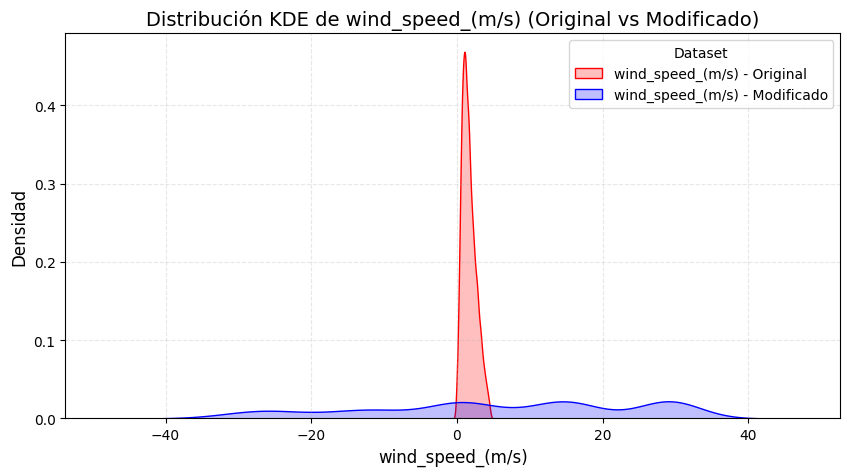

Métricas obtenidas al modificar wind_speed_(m/s):



{'Variable_a_modificar': 'wind_speed_(m/s)',
 'mean_shift_%': '0.15',
 'rmse': 135.7030701012492,
 'mae': 82.7229878141192,
 'mape': 1.6748911856787142e+16,
 'r2': 0.9483563633800727,
 'explained_variance': 0.9547900951576449,
 'median_ae': 45.113525390625,
 'mean_bias_error': -47.897488341234805}

In [23]:
gmm_windspeed = GaussianMixture(n_components=5, random_state=42).fit(df_featured['wind_speed_(m/s)'].to_numpy().reshape(-1,1))
wind_metrics = test_numerical_drift('wind_speed_(m/s)', gmm_dew, 0.15)
wind_metrics

## Usando `temperature(°c)`

Medias originales de temperature(°c): 
 [[-12.05358494]
 [ 29.02195515]
 [-26.20717527]
 [ 14.78137318]
 [  1.03553534]]


Medias alteradas temperature(°c): 
 [[-12.65626419]
 [ 30.47305291]
 [-27.51753404]
 [ 15.52044184]
 [  1.08731211]]
Sí se detectó drift.


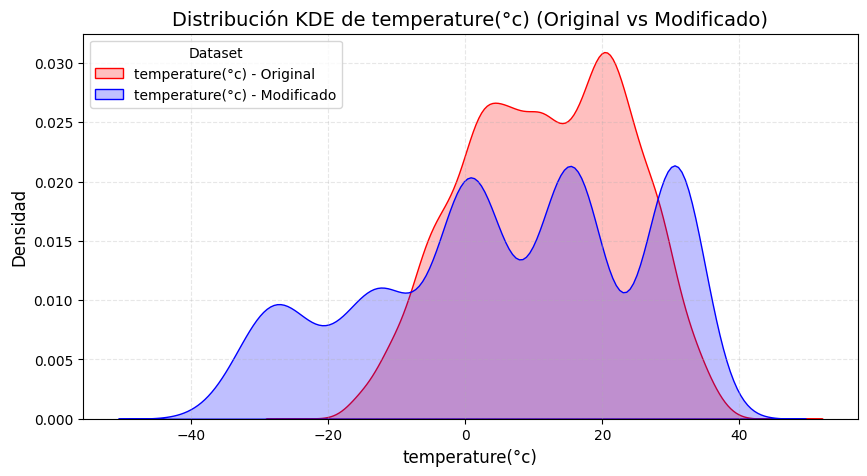

Métricas obtenidas al modificar temperature(°c):



{'Variable_a_modificar': 'temperature(°c)',
 'mean_shift_%': '0.05',
 'rmse': 447.70110975614676,
 'mae': 297.7556822166549,
 'mape': 7.774615155756869e+16,
 'r2': 0.4378997062599548,
 'explained_variance': 0.43827038572679367,
 'median_ae': 168.71917724609375,
 'mean_bias_error': -11.496894063403}

In [19]:
gmm_windspeed = GaussianMixture(n_components=5, random_state=42).fit(df_featured['temperature(°c)'].to_numpy().reshape(-1,1))
temp_metrics = test_numerical_drift('temperature(°c)', gmm_dew, 0.05)
temp_metrics

## Comparando el desempeño Baseline con las simulaciones de Drift

In [20]:
metrics = [ baseline_metrics_dict, dew_shift_metrics, wind_metrics, temp_metrics ]

df_KSDrift_metrics = pd.DataFrame(metrics)

display(df_KSDrift_metrics)

,Variable_a_modificar,mean_shift_%,rmse,mae,mape,r2,explained_variance,median_ae,mean_bias_error
0,Ninguna,0,170.358371,92.319869,1.644164e+16,0.919033,0.919037,47.023636,-1.297919
1,dew_point_temperature(°c),0.25,152.975901,99.901672,1.561668e+16,0.934373,0.934953,61.405975,-14.388716
2,wind_speed_(m/s),0.15,135.703070,82.722988,1.674891e+16,0.948356,0.954790,45.113525,-47.897488
3,temperature(°c),0.05,447.701110,297.755682,7.774615e+16,0.437900,0.438270,168.719177,-11.496894
